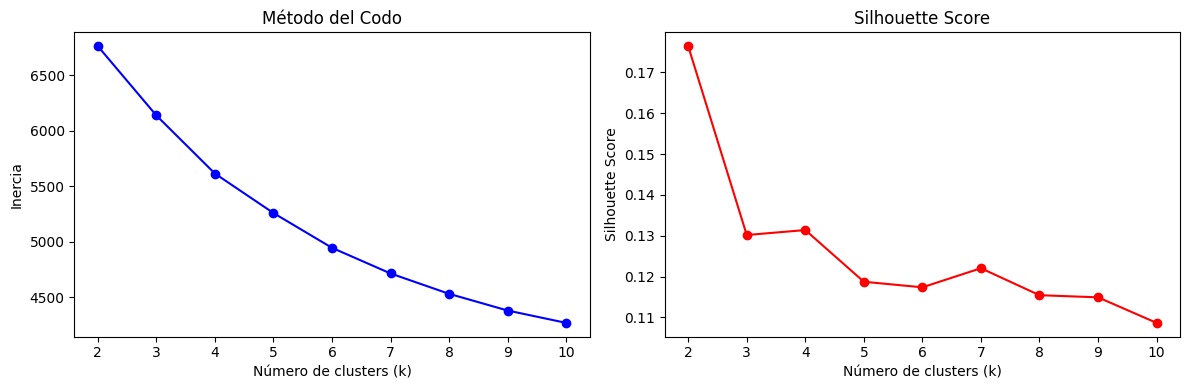

Métricas de evaluación:
Silhouette Score (K-Means): 0.130
Davies-Bouldin (K-Means): 2.008


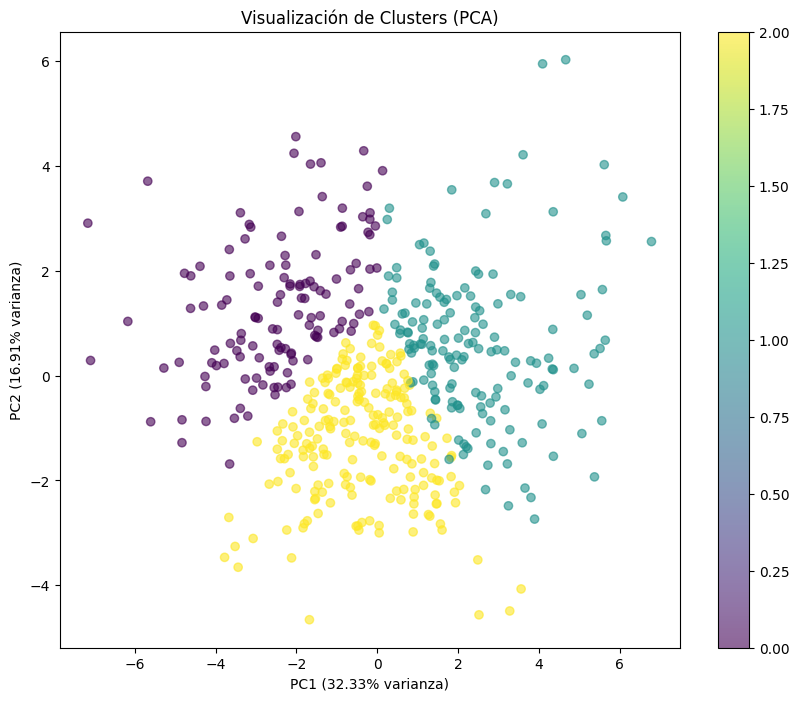


Características promedio por cluster:
                    length         dz  tortuosity  bottleneck_radius  \
cluster_kmeans                                                         
0               150.367677  78.234535    1.922034           0.188622   
1               157.227610  78.646893    1.999176           0.233145   
2               140.748228  77.840884    1.807938           0.333837   

                bottleneck_free_radius  bottleneck_bradius    n_layers  \
cluster_kmeans                                                           
0                             0.282756            0.188622  126.291339   
1                             0.337824            0.233145  136.503145   
2                             0.489702            0.333837  119.386047   

                  charge  num_positives  num_negatives  hydrophobicity  \
cluster_kmeans                                                           
0               0.653543       5.921260       5.267717        0.218425   
1      

In [21]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar tus datos (asumiendo que ya tienes el DataFrame)
mole_results = pd.read_csv('/media/leandro/My Passport/TMEM63A/MD_50current/results_features_state0.csv')

# 2. Seleccionar las columnas numéricas para clustering
feature_columns = ['length', 'dz', 'tortuosity', 'bottleneck_radius',
                   'bottleneck_free_radius', 'bottleneck_bradius', 'n_layers', 
                   'charge', 'num_positives', 'num_negatives', 'hydrophobicity',
                   'hydropathy', 'polarity', 'logp', 'logd', 'logs', 'mutability']

# Si tienes columnas categóricas como 'ionizable', puedes codificarlas
# mole_results['ionizable_encoded'] = mole_results['ionizable'].astype(int)

# 3. Preparar los datos
X = mole_results[feature_columns].copy()

# Manejar valores nulos si los hay
X = X.fillna(X.mean())

# 4. Escalar los datos (importante para clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Determinar número óptimo de clusters con el método del codo
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Visualizar método del codo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del Codo')

axes[1].plot(K_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')

plt.tight_layout()
plt.show()

# 6. Elegir el número óptimo (ejemplo: k=3 si parece adecuado)
optimal_k = 3  # Ajusta según tus gráficos

# 7. Aplicar clustering
# Opción A: K-Means
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
mole_results['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

# Opción B: Clustering jerárquico
hierarchical = AgglomerativeClustering(n_clusters=optimal_k)
mole_results['cluster_hierarchical'] = hierarchical.fit_predict(X_scaled)

# Opción C: DBSCAN (no requiere número de clusters)
dbscan = DBSCAN(eps=0.5, min_samples=5)
mole_results['cluster_dbscan'] = dbscan.fit_predict(X_scaled)

# 8. Evaluar calidad del clustering
print("Métricas de evaluación:")
print(f"Silhouette Score (K-Means): {silhouette_score(X_scaled, mole_results['cluster_kmeans']):.3f}")
print(f"Davies-Bouldin (K-Means): {davies_bouldin_score(X_scaled, mole_results['cluster_kmeans']):.3f}")

# 9. Visualizar clusters con PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                      c=mole_results['cluster_kmeans'], cmap='viridis', alpha=0.6)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} varianza)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} varianza)')
plt.title('Visualización de Clusters (PCA)')
plt.colorbar(scatter)
plt.show()

# 10. Analizar características de cada cluster
cluster_summary = mole_results.groupby('cluster_kmeans')[feature_columns].mean()
print("\nCaracterísticas promedio por cluster:")
print(cluster_summary)

# 11. Análisis de importancia de features por cluster (opcional)
# Usar el centroide de K-Means para ver qué features diferencian más
feature_importance = pd.DataFrame(
    kmeans.cluster_centers_, 
    columns=feature_columns
)
print("\nCentroides normalizados por cluster:")
print(feature_importance)

# 12. Guardar resultados
mole_results.to_csv('clustering_results.csv', index=False)

Features totales: 18 originales + 74 temporales = 92

Número óptimo de clusters: 2


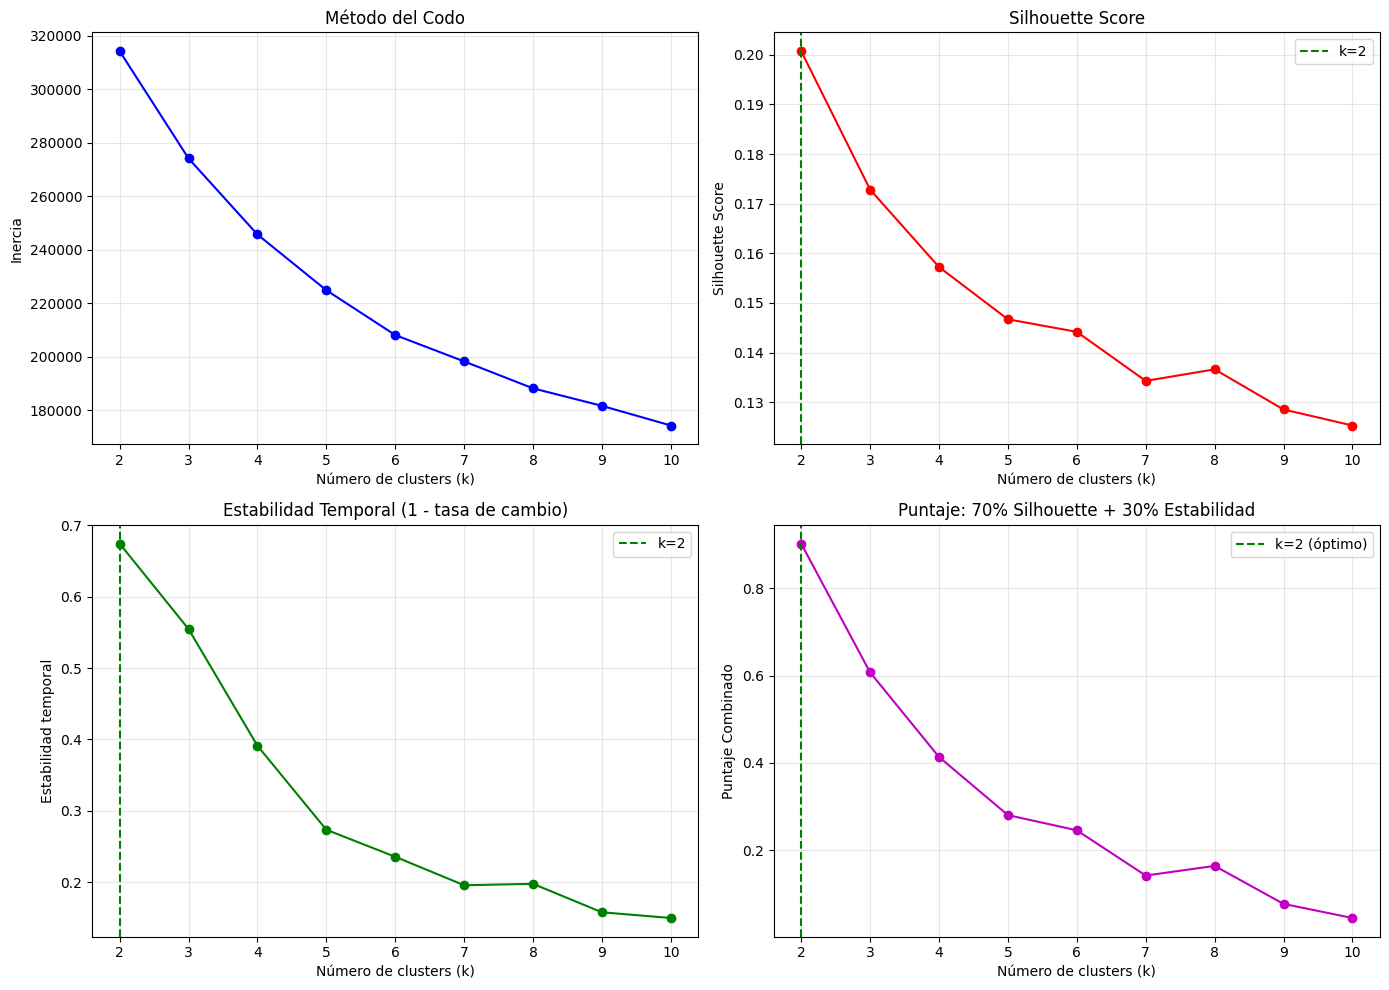


Aplicando clustering jerárquico...

Silhouette Score K-Means: 0.201
Silhouette Score Jerárquico: 0.217

Transiciones detectadas: 163

Primeras 5 transiciones:
   frame  next_frame  from_cluster  to_cluster  duration_in_cluster
0    1.0         2.0             1           0                    0
1    4.0         5.0             0           1                    3
2   11.0        12.0             1           0                    7
3   12.0        13.0             0           1                    1
4   17.0        18.0             1           0                    5


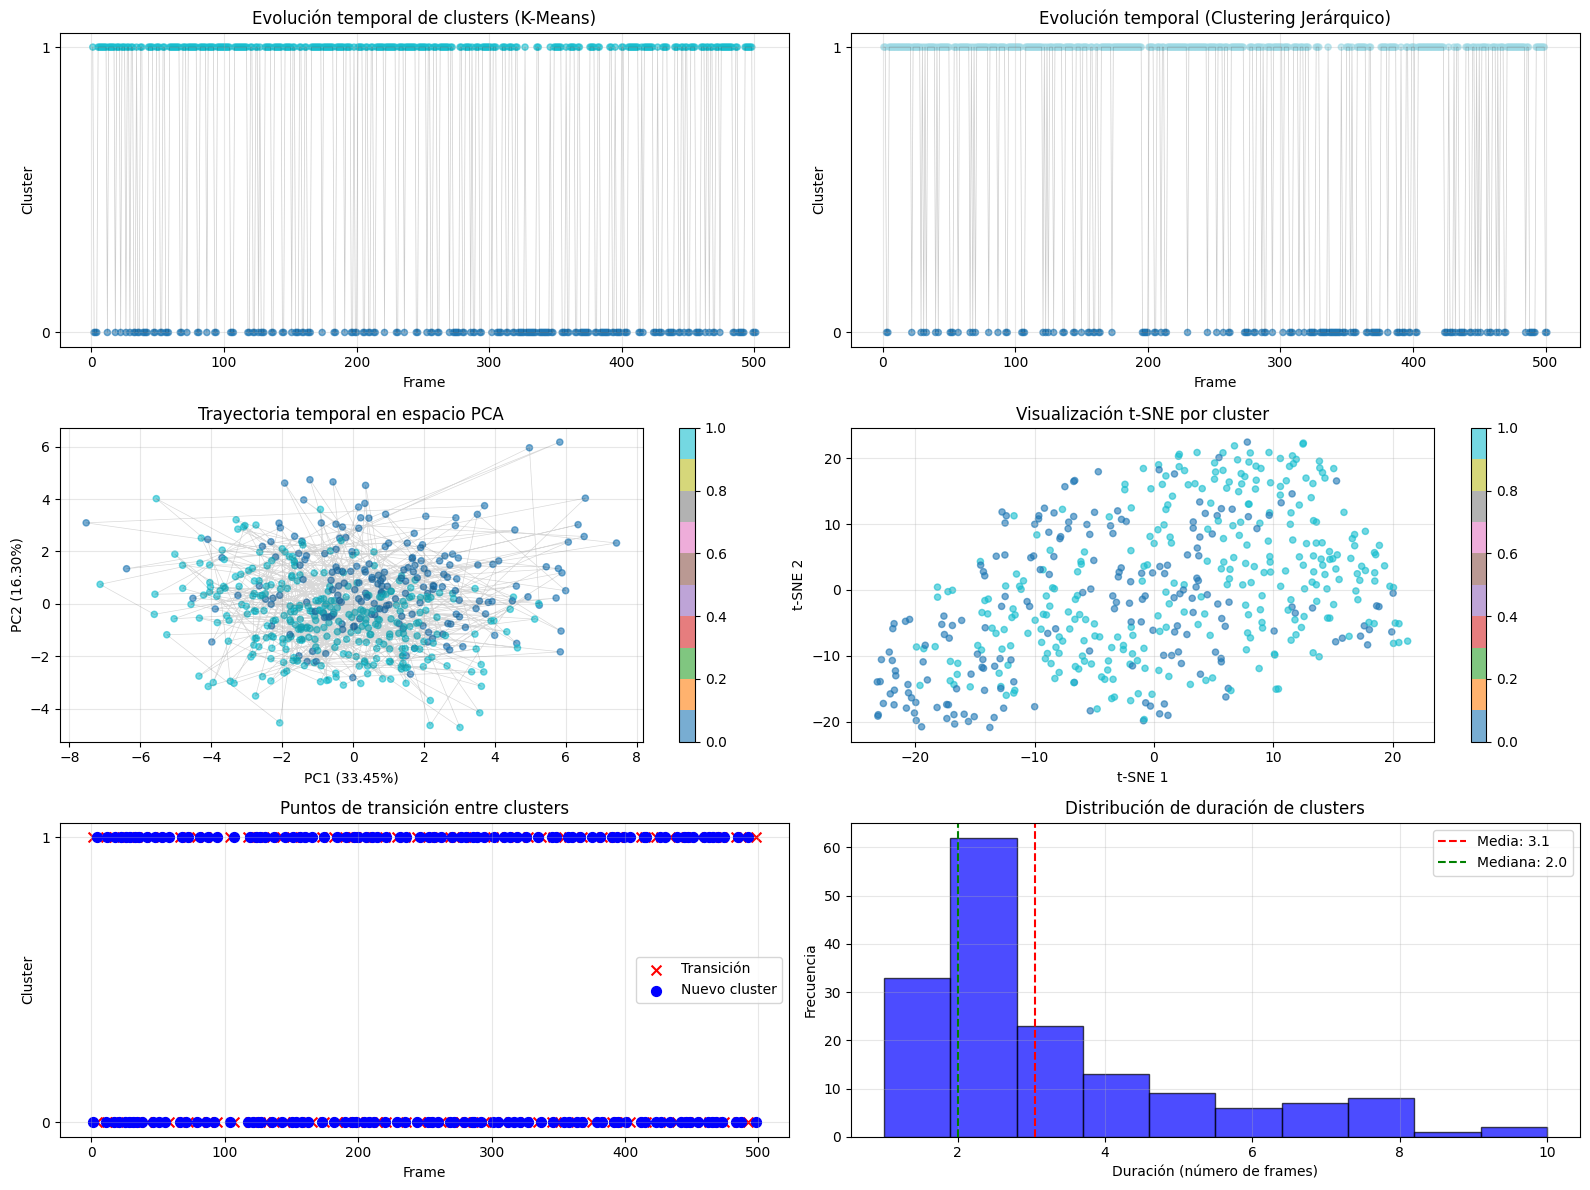


Caracterización temporal de clusters:
         start_frame  end_frame  duration_frames  frame_<lambda_0>  \
cluster                                                              
0                  2        501              195               499   
1                  1        498              306               497   

         length_mean  length_std  dz_mean  dz_std  tortuosity_mean  \
cluster                                                              
0            158.072      11.865   78.982    2.42            2.002   
1            142.264       8.744   77.696    1.96            1.831   

         tortuosity_std  ...  logp_mean  logp_std  logd_mean  logd_std  \
cluster                  ...                                             
0                 0.139  ...      0.849     0.127      0.268     0.180   
1                 0.107  ...      0.895     0.130      0.314     0.179   

         logs_mean  logs_std  mutability_mean  mutability_std  \
cluster                              

In [22]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

# 1. Cargar datos y asegurar orden temporal
df = mole_results
df = df.sort_values('frame').reset_index(drop=True)

# 2. Preparar features (escalado)
feature_columns = ['length', 'dz', 'tortuosity', 'bottleneck_radius',
                   'bottleneck_free_radius', 'bottleneck_bradius', 'n_layers', 
                   'charge', 'num_positives', 'num_negatives', 'hydrophobicity',
                   'hydropathy', 'polarity', 'logp', 'logd', 'logs', 'mutability']

# Codificar ionizable si es necesario
if 'ionizable' in df.columns:
    df['ionizable_encoded'] = df['ionizable'].astype(int)
    feature_columns.append('ionizable_encoded')

X = df[feature_columns].copy()
X = X.fillna(X.mean())

# Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. CREAR FEATURES TEMPORALES (crucial para frames)
def create_temporal_features(df, features, window_size=5):
    """Crea features derivadas que capturan dinámica temporal"""
    temporal_features = []
    
    for feature in features:
        # Derivada (velocidad de cambio)
        derivative = np.gradient(df[feature].values)
        temporal_features.append(derivative)
        
        # Suavizado para reducir ruido
        if len(df) > window_size:
            smoothed = savgol_filter(df[feature].values, window_size if window_size % 2 == 1 else window_size+1, 2)
            temporal_features.append(smoothed)
        
        # Aceleración (segunda derivada)
        acceleration = np.gradient(np.gradient(df[feature].values))
        temporal_features.append(acceleration)
        
        # Tasa de cambio relativa
        relative_change = np.gradient(np.log(df[feature].values + 1e-10))
        temporal_features.append(relative_change)
    
    # Calcular similitud entre frames consecutivos (correlación)
    correlation = []
    for i in range(len(df)-1):
        corr = np.corrcoef(df.iloc[i][features].values, df.iloc[i+1][features].values)[0,1]
        correlation.append(corr)
    correlation.append(np.nan)  # último frame no tiene siguiente
    
    # Calcular distancia euclidiana entre frames consecutivos
    distances = []
    for i in range(len(df)-1):
        dist = np.linalg.norm(df.iloc[i][features].values - df.iloc[i+1][features].values)
        distances.append(dist)
    distances.append(np.nan)
    
    # Crear DataFrame con features temporales
    temp_df = pd.DataFrame()
    for idx, arr in enumerate(temporal_features):
        temp_df[f'temp_feat_{idx}'] = arr
    
    temp_df['frame_correlation'] = correlation
    temp_df['frame_distance'] = distances
    
    return temp_df.fillna(0)

# Generar features temporales
temporal_features_df = create_temporal_features(df, feature_columns, window_size=5)

# Combinar features originales con temporales
X_enhanced = np.hstack([X_scaled, temporal_features_df.values])
print(f"Features totales: {X_scaled.shape[1]} originales + {temporal_features_df.shape[1]} temporales = {X_enhanced.shape[1]}")

# 4. DETERMINAR NÚMERO ÓPTIMO DE CLUSTERS CON ENFOQUE TEMPORAL
def find_optimal_k_temporal(X, max_k=10):
    """Encuentra k óptimo considerando la continuidad temporal"""
    silhouette_scores = []
    inertias = []
    temporal_stability = []
    K_range = range(2, min(max_k + 1, len(X)//2))
    
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        
        # Silhouette score
        if len(set(labels)) > 1:
            silhouette_scores.append(silhouette_score(X, labels))
        else:
            silhouette_scores.append(-1)
        
        inertias.append(kmeans.inertia_)
        
        # Estabilidad temporal: qué tan seguido cambian los clusters
        changes = np.sum(labels[:-1] != labels[1:])
        change_rate = changes / len(labels)
        temporal_stability.append(1 - change_rate)  # 1 = muy estable
    
    # Normalizar métricas para combinarlas
    silhouette_norm = (silhouette_scores - np.min(silhouette_scores)) / (np.max(silhouette_scores) - np.min(silhouette_scores) + 1e-10)
    
    # Puntaje combinado: balance entre silueta y estabilidad
    combined_score = 0.7 * silhouette_norm + 0.3 * np.array(temporal_stability)
    
    # El mejor k es el que maximiza el puntaje combinado
    optimal_k = K_range[np.argmax(combined_score)]
    
    return optimal_k, K_range, silhouette_scores, inertias, temporal_stability

optimal_k, K_range, silhouette_scores, inertias, temporal_stability = find_optimal_k_temporal(X_enhanced)

print(f"\nNúmero óptimo de clusters: {optimal_k}")

# Visualizar métricas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(K_range, inertias, 'bo-')
axes[0, 0].set_xlabel('Número de clusters (k)')
axes[0, 0].set_ylabel('Inercia')
axes[0, 0].set_title('Método del Codo')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(K_range, silhouette_scores, 'ro-')
axes[0, 1].set_xlabel('Número de clusters (k)')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].set_title('Silhouette Score')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axvline(optimal_k, color='green', linestyle='--', label=f'k={optimal_k}')
axes[0, 1].legend()

axes[1, 0].plot(K_range, temporal_stability, 'go-')
axes[1, 0].set_xlabel('Número de clusters (k)')
axes[1, 0].set_ylabel('Estabilidad temporal')
axes[1, 0].set_title('Estabilidad Temporal (1 - tasa de cambio)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axvline(optimal_k, color='green', linestyle='--', label=f'k={optimal_k}')
axes[1, 0].legend()

# Puntaje combinado
combined_scores = []
for i, k in enumerate(K_range):
    if len(K_range) > 0 and i < len(silhouette_scores):
        sil_norm = (silhouette_scores[i] - min(silhouette_scores)) / (max(silhouette_scores) - min(silhouette_scores) + 1e-10)
        combined = 0.7 * sil_norm + 0.3 * temporal_stability[i]
        combined_scores.append(combined)

axes[1, 1].plot(K_range, combined_scores, 'mo-')
axes[1, 1].set_xlabel('Número de clusters (k)')
axes[1, 1].set_ylabel('Puntaje Combinado')
axes[1, 1].set_title('Puntaje: 70% Silhouette + 30% Estabilidad')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axvline(optimal_k, color='green', linestyle='--', label=f'k={optimal_k} (óptimo)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# 5. CLUSTERING CON K-MEANS Y CONSIDERACIÓN TEMPORAL
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_enhanced)

# Clustering jerárquico para comparación (usando la matriz de distancia temporal)
print("\nAplicando clustering jerárquico...")
hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
df['cluster_hierarchical'] = hierarchical.fit_predict(X_enhanced)

# Evaluar ambos métodos
print(f"\nSilhouette Score K-Means: {silhouette_score(X_enhanced, df['cluster']):.3f}")
print(f"Silhouette Score Jerárquico: {silhouette_score(X_enhanced, df['cluster_hierarchical']):.3f}")

# 6. ANÁLISIS DE TRANSICIONES TEMPORALES
def analyze_temporal_transitions(df):
    """Analiza cómo cambian los clusters en el tiempo"""
    clusters = df['cluster'].values
    transitions = []
    last_transition = 0
    
    for i in range(len(clusters)-1):
        if clusters[i] != clusters[i+1]:
            transitions.append({
                'frame': df.iloc[i]['frame'],
                'next_frame': df.iloc[i+1]['frame'],
                'from_cluster': clusters[i],
                'to_cluster': clusters[i+1],
                'duration_in_cluster': i - last_transition
            })
            last_transition = i
    
    return pd.DataFrame(transitions)

transitions_df = analyze_temporal_transitions(df)

print(f"\nTransiciones detectadas: {len(transitions_df)}")
if len(transitions_df) > 0:
    print("\nPrimeras 5 transiciones:")
    print(transitions_df.head())

# 7. VISUALIZACIÓN TEMPORAL COMPLETA
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# A) Evolución temporal de clusters
ax1 = axes[0, 0]
frames = df['frame'].values
clusters = df['cluster'].values

ax1.scatter(frames, clusters, c=clusters, cmap='tab10', alpha=0.6, s=20)
ax1.plot(frames, clusters, 'k-', alpha=0.2, linewidth=0.5)
ax1.set_xlabel('Frame')
ax1.set_ylabel('Cluster')
ax1.set_title('Evolución temporal de clusters (K-Means)')
ax1.set_yticks(range(optimal_k))
ax1.grid(True, alpha=0.3)

# B) Vista del mismo con jerárquico para comparar
ax2 = axes[0, 1]
clusters_hier = df['cluster_hierarchical'].values
ax2.scatter(frames, clusters_hier, c=clusters_hier, cmap='tab20', alpha=0.6, s=20)
ax2.plot(frames, clusters_hier, 'k-', alpha=0.2, linewidth=0.5)
ax2.set_xlabel('Frame')
ax2.set_ylabel('Cluster')
ax2.set_title('Evolución temporal (Clustering Jerárquico)')
ax2.set_yticks(range(optimal_k))
ax2.grid(True, alpha=0.3)

# C) PCA con trayectoria temporal
ax3 = axes[1, 0]
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Colorear por cluster pero mostrar trayectoria
scatter = ax3.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'], cmap='tab10', alpha=0.6, s=20)
ax3.plot(X_pca[:, 0], X_pca[:, 1], 'k-', alpha=0.15, linewidth=0.5)
ax3.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
ax3.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
ax3.set_title('Trayectoria temporal en espacio PCA')
ax3.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax3)

# D) t-SNE para mejor separación
ax4 = axes[1, 1]
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(df)//5))
X_tsne = tsne.fit_transform(X_scaled)
scatter2 = ax4.scatter(X_tsne[:, 0], X_tsne[:, 1], c=df['cluster'], cmap='tab10', alpha=0.6, s=20)
ax4.set_xlabel('t-SNE 1')
ax4.set_ylabel('t-SNE 2')
ax4.set_title('Visualización t-SNE por cluster')
ax4.grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=ax4)

# E) Cambios temporales (detección de eventos)
ax5 = axes[2, 0]
if len(transitions_df) > 0:
    ax5.scatter(transitions_df['frame'], transitions_df['from_cluster'], 
               color='red', s=50, marker='x', label='Transición')
    ax5.scatter(transitions_df['frame'], transitions_df['to_cluster'], 
               color='blue', s=50, marker='o', label='Nuevo cluster')
    ax5.legend()
ax5.set_xlabel('Frame')
ax5.set_ylabel('Cluster')
ax5.set_title('Puntos de transición entre clusters')
ax5.grid(True, alpha=0.3)
ax5.set_yticks(range(optimal_k))

# F) Distribución de duración de clusters
ax6 = axes[2, 1]
cluster_durations = []
current_cluster = clusters[0]
duration = 1
for c in clusters[1:]:
    if c == current_cluster:
        duration += 1
    else:
        cluster_durations.append(duration)
        current_cluster = c
        duration = 1
cluster_durations.append(duration)

if cluster_durations:
    ax6.hist(cluster_durations, bins=min(30, len(set(cluster_durations))), alpha=0.7, color='blue', edgecolor='black')
    ax6.axvline(np.mean(cluster_durations), color='red', linestyle='--', 
                label=f'Media: {np.mean(cluster_durations):.1f}')
    ax6.axvline(np.median(cluster_durations), color='green', linestyle='--', 
                label=f'Mediana: {np.median(cluster_durations):.1f}')
    ax6.set_xlabel('Duración (número de frames)')
    ax6.set_ylabel('Frecuencia')
    ax6.set_title('Distribución de duración de clusters')
    ax6.legend()
    ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 8. CARACTERIZACIÓN DE CLUSTERS POR PERIODO TEMPORAL
cluster_summary = df.groupby('cluster').agg({
    'frame': ['min', 'max', 'count', lambda x: x.max() - x.min()],
    **{col: ['mean', 'std'] for col in feature_columns if col in df.columns}
}).round(3)

cluster_summary.columns = ['_'.join(col).strip() for col in cluster_summary.columns.values]
cluster_summary = cluster_summary.rename(columns={
    'frame_min': 'start_frame',
    'frame_max': 'end_frame',
    'frame_count': 'duration_frames',
    'frame_<lambda>': 'timespan'
})

print("\nCaracterización temporal de clusters:")
print(cluster_summary)

# 9. MATRIZ DE CORRELACIÓN TEMPORAL
corr_matrix = np.zeros((optimal_k, optimal_k))
for i in range(optimal_k):
    for j in range(optimal_k):
        if i == j:
            corr_matrix[i, j] = 0
        else:
            # Probabilidad de transición de i a j
            transitions_i = transitions_df[transitions_df['from_cluster'] == i]
            if len(transitions_i) > 0:
                prob = len(transitions_i[transitions_i['to_cluster'] == j]) / len(transitions_i)
                corr_matrix[i, j] = prob
            else:
                corr_matrix[i, j] = 0

# 10. DETECCIÓN DE EVENTOS SIGNIFICATIVOS
def detect_significant_events(df, threshold_percentile=95):
    """Detecta eventos basados en cambios abruptos en las features"""
    events = []
    
    for i in range(len(df) - 1):
        current = df.iloc[i][feature_columns].values
        next_frame = df.iloc[i + 1][feature_columns].values
        
        # Cambio absoluto
        abs_change = np.abs(current - next_frame)
        max_change = np.max(abs_change)
        mean_change = np.mean(abs_change)
        
        # Cambio relativo (evita división por cero)
        relative_change = np.abs((next_frame - current) / (current + 1e-10))
        max_rel_change = np.max(relative_change)
        
        # Distancia euclidiana
        distance = np.linalg.norm(current - next_frame)
        
        # Feature con mayor cambio
        max_change_feature = feature_columns[np.argmax(abs_change)]
        
        if distance > threshold_percentile:
            events.append({
                'frame': df.iloc[i]['frame'],
                'next_frame': df.iloc[i + 1]['frame'],
                'distance': distance,
                'max_abs_change': max_change,
                'max_rel_change': max_rel_change,
                'feature_changed': max_change_feature,
                'from_cluster': df.iloc[i]['cluster'],
                'to_cluster': df.iloc[i + 1]['cluster']
            })
    
    return pd.DataFrame(events)

threshold = np.percentile(temporal_features_df['frame_distance'].values, 90)
events_df = detect_significant_events(df, threshold_percentile=threshold)

print(f"\nEventos significativos detectados: {len(events_df)}")
if len(events_df) > 0:
    print("\nTop 5 eventos más significativos:")
    print(events_df.nlargest(5, 'distance'))

# 11. EXPORTAR RESULTADOS PARA ANÁLISIS POSTERIOR
df.to_csv('clustering_temporal_results.csv', index=False)
transitions_df.to_csv('temporal_transitions.csv', index=False)
if len(events_df) > 0:
    events_df.to_csv('significant_events.csv', index=False)
cluster_summary.to_csv('cluster_temporal_summary.csv')

print("\n" + "="*60)
print("RESUMEN FINAL")
print("="*60)
print(f"Total de frames analizados: {len(df)}")
print(f"Clusters óptimos: {optimal_k}")
print(f"Transiciones entre clusters: {len(transitions_df)}")
print(f"Eventos significativos: {len(events_df)}")
print(f"Duración promedio de cluster: {np.mean(cluster_durations):.1f} frames")
print(f"Cluster más duradero: {cluster_summary['duration_frames'].idxmax()} con {cluster_summary['duration_frames'].max():.0f} frames")
print(f"Cluster menos duradero: {cluster_summary['duration_frames'].idxmin()} con {cluster_summary['duration_frames'].min():.0f} frames")

## Análisis convolucional

Features originales: 18
Features convolucionales generadas: 792
Total features: 810
Features espectrales añadidas: 144
Total features finales: 954
Features wavelet añadidas: 216

Número óptimo de clusters: 2


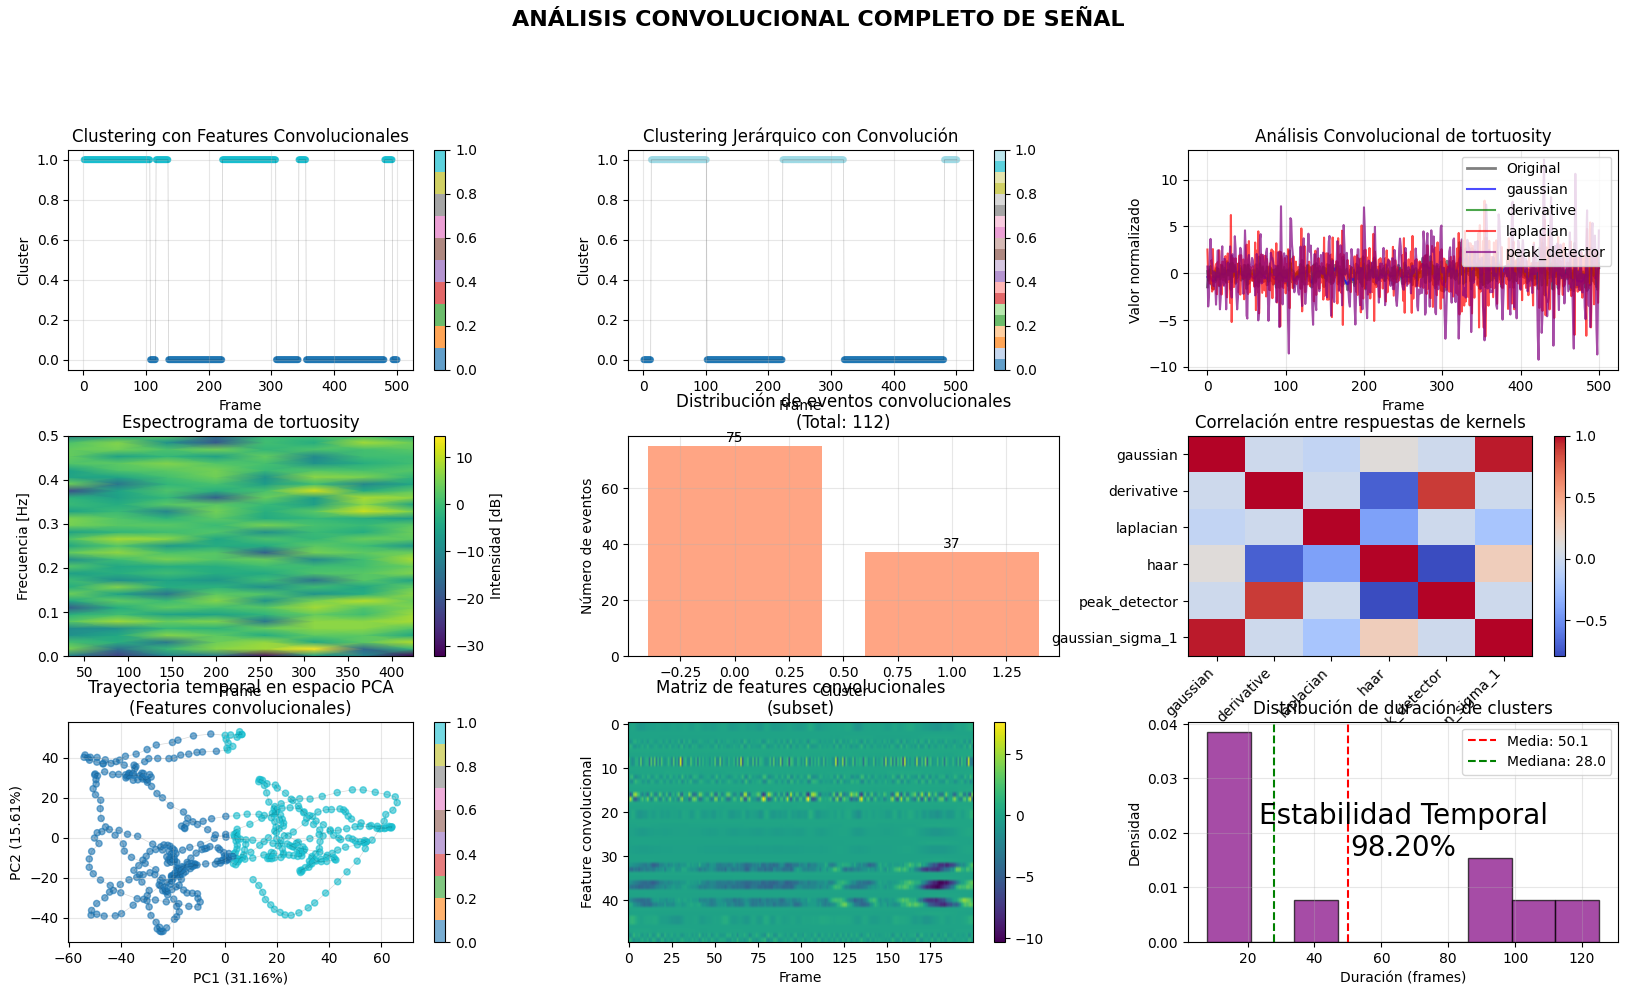


Estadísticas de clusters convolucionales:
             frame             length              dz        tortuosity  \
             count  min  max     mean     std    mean    std       mean   
cluster_conv                                                              
0              264  107  501  150.793  13.757  78.561  2.267      1.919   
1              237    1  493  145.770  10.789  77.790  2.137      1.874   

                    bottleneck_radius  ...   logp          logd          logs  \
                std              mean  ...   mean    std   mean    std   mean   
cluster_conv                           ...                                      
0             0.157             0.247  ...  0.832  0.124  0.231  0.179 -0.014   
1             0.130             0.285  ...  0.928  0.119  0.369  0.154 -0.120   

                    mutability        ionizable_encoded         
                std       mean    std              mean    std  
cluster_conv                                 

In [23]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import convolve, correlate, find_peaks, spectrogram
from scipy.ndimage import gaussian_filter1d
from scipy.fft import fft, fftfreq, ifft
from scipy.stats import kurtosis, skew
import pywt  # Para wavelet transform
import warnings
warnings.filterwarnings('ignore')

# 1. Cargar y preparar datos
df = mole_results
df = df.sort_values('frame').reset_index(drop=True)

feature_columns = ['length', 'dz', 'tortuosity', 'bottleneck_radius',
                   'bottleneck_free_radius', 'bottleneck_bradius', 'n_layers', 
                   'charge', 'num_positives', 'num_negatives', 'hydrophobicity',
                   'hydropathy', 'polarity', 'logp', 'logd', 'logs', 'mutability']

if 'ionizable' in df.columns:
    df['ionizable_encoded'] = df['ionizable'].astype(int)
    feature_columns.append('ionizable_encoded')

X = df[feature_columns].copy()
X = X.fillna(X.mean())

# Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================
# 1. ANÁLISIS CONVOLUCIONAL DE SEÑAL
# ============================================

def create_convolutional_kernels():
    """Crea diferentes kernels para análisis convolucional"""
    kernels = {}
    
    # Kernel gaussiano (suavizado)
    gaussian = np.exp(-np.linspace(-3, 3, 11)**2 / 2)
    gaussian = gaussian / gaussian.sum()
    kernels['gaussian'] = gaussian
    
    # Kernel derivativo (detección de bordes/transiciones)
    deriv = np.array([-1, 0, 1]) / 2
    kernels['derivative'] = deriv
    
    # Kernel laplaciano (detección de cambios abruptos)
    laplacian = np.array([1, -2, 1])
    kernels['laplacian'] = laplacian
    
    # Kernel de Haar (detección de ondas)
    haar = np.array([1, 1, -1, -1]) / 2
    kernels['haar'] = haar
    
    # Kernel para detección de picos
    peak_detector = np.array([-1, -2, 0, 2, 1])
    kernels['peak_detector'] = peak_detector
    
    # Kernel de suavizado con diferente escala
    for sigma in [1, 3, 5]:
        kernel = np.exp(-np.linspace(-3*sigma, 3*sigma, 6*sigma+1)**2 / (2*sigma**2))
        kernel = kernel / kernel.sum()
        kernels[f'gaussian_sigma_{sigma}'] = kernel
    
    # Kernel para detección de oscilaciones
    for freq in [0.1, 0.2, 0.3]:
        t = np.linspace(0, 4*np.pi, 20)
        kernel = np.sin(freq * t)
        kernels[f'oscillation_{freq}'] = kernel
    
    return kernels

def apply_convolutional_analysis(data, kernels):
    """Aplica análisis convolucional a los datos"""
    conv_features = []
    feature_names = []
    
    for feature_idx in range(data.shape[1]):
        signal = data[:, feature_idx]
        
        for kernel_name, kernel in kernels.items():
            # Convolución directa
            conv_result = convolve(signal, kernel, mode='same')
            conv_features.append(conv_result)
            feature_names.append(f'conv_{feature_idx}_{kernel_name}')
            
            # Correlación cruzada (para alineación temporal)
            corr_result = correlate(signal, kernel, mode='same')
            conv_features.append(corr_result)
            feature_names.append(f'corr_{feature_idx}_{kernel_name}')
            
            # Detectando picos en la convolución (eventos)
            peaks, _ = find_peaks(np.abs(conv_result), height=np.std(conv_result)*0.5)
            peak_density = len(peaks) / len(signal)
            
            # Características de la convolución
            conv_features.append(np.ones(len(signal)) * peak_density)
            feature_names.append(f'peak_density_{feature_idx}_{kernel_name}')
            
            # Energía de la convolución (ventana móvil)
            window_size = 10
            energy = np.array([np.sum(conv_result[max(0,i-window_size):min(len(signal),i+window_size)]**2) 
                              for i in range(len(signal))])
            conv_features.append(energy / (energy.max() + 1e-10))
            feature_names.append(f'energy_{feature_idx}_{kernel_name}')
    
    return np.column_stack(conv_features), feature_names

# Aplicar análisis convolucional
kernels = create_convolutional_kernels()
X_conv, conv_feature_names = apply_convolutional_analysis(X_scaled, kernels)

print(f"Features originales: {X_scaled.shape[1]}")
print(f"Features convolucionales generadas: {X_conv.shape[1]}")
print(f"Total features: {X_scaled.shape[1] + X_conv.shape[1]}")

# Combinar features originales con convolucionales
X_combined = np.hstack([X_scaled, X_conv])

# ============================================
# 2. ANÁLISIS DE FRECUENCIA (ESPECTROGRAMA)
# ============================================

def extract_spectral_features(data, fs=1.0):
    """Extrae features espectrales de la señal"""
    spectral_features = []
    
    for feature_idx in range(data.shape[1]):
        signal = data[:, feature_idx]
        
        # FFT de la señal completa
        fft_vals = fft(signal)
        freqs = fftfreq(len(signal), 1/fs)
        magnitude = np.abs(fft_vals)
        
        # Potencia en diferentes bandas de frecuencia
        bands = [(0, 0.1), (0.1, 0.2), (0.2, 0.3), (0.3, 0.5)]
        for low, high in bands:
            mask = (freqs >= low) & (freqs <= high)
            band_power = np.sum(magnitude[mask]**2)
            spectral_features.append(np.ones(len(signal)) * band_power)
        
        # Feature: frecuencia dominante
        dominant_freq = freqs[np.argmax(magnitude[1:]) + 1]
        spectral_features.append(np.ones(len(signal)) * dominant_freq)
        
        # Feature: energía espectral
        spectral_energy = np.sum(magnitude**2)
        spectral_features.append(np.ones(len(signal)) * spectral_energy)
        
        # Espectrograma (ventana deslizante)
        f, t, Sxx = spectrogram(signal, fs, nperseg=min(64, len(signal)//4))
        
        # Estadísticas del espectrograma
        spectral_centroid = np.sum(f[:, None] * Sxx, axis=0) / (np.sum(Sxx, axis=0) + 1e-10)
        spectral_spread = np.sqrt(np.sum(((f[:, None] - spectral_centroid)**2) * Sxx, axis=0) / (np.sum(Sxx, axis=0) + 1e-10))
        
        # Interpolar para que coincida con la longitud de la señal
        spectral_centroid_interp = np.interp(np.linspace(0, len(signal)-1, len(signal)), 
                                            np.linspace(0, len(signal)-1, len(spectral_centroid)), 
                                            spectral_centroid)
        spectral_spread_interp = np.interp(np.linspace(0, len(signal)-1, len(signal)), 
                                          np.linspace(0, len(signal)-1, len(spectral_spread)), 
                                          spectral_spread)
        
        spectral_features.append(spectral_centroid_interp)
        spectral_features.append(spectral_spread_interp)
    
    return np.column_stack(spectral_features)

X_spectral = extract_spectral_features(X_scaled)
X_combined = np.hstack([X_combined, X_spectral])
print(f"Features espectrales añadidas: {X_spectral.shape[1]}")
print(f"Total features finales: {X_combined.shape[1]}")

# ============================================
# 3. ANÁLISIS WAVELET
# ============================================

def wavelet_analysis(data, wavelet='db4', level=3):
    """Realiza análisis wavelet de la señal"""
    wavelet_features = []
    
    for feature_idx in range(data.shape[1]):
        signal = data[:, feature_idx]
        
        # Transformada wavelet discreta
        coeffs = pywt.wavedec(signal, wavelet, level=level)
        
        # Extraer estadísticas de cada nivel
        for level_idx, coeff in enumerate(coeffs):
            # Estadísticas de los coeficientes
            mean_coeff = np.mean(np.abs(coeff))
            std_coeff = np.std(coeff)
            energy_coeff = np.sum(coeff**2)
            
            # Crear señales de la misma longitud para todas las estadísticas
            wavelet_features.append(np.ones(len(signal)) * mean_coeff)
            wavelet_features.append(np.ones(len(signal)) * std_coeff)
            wavelet_features.append(np.ones(len(signal)) * energy_coeff)
            
            # Reconstrucción parcial para ver tendencias
            if level_idx <= 1:  # Solo niveles bajos (tendencia)
                rec_signal = pywt.waverec(coeffs[:level_idx+1] + [np.zeros_like(c) for c in coeffs[level_idx+1:]], wavelet)
                if len(rec_signal) == len(signal):
                    wavelet_features.append(rec_signal)
    
    return np.column_stack(wavelet_features)

X_wavelet = wavelet_analysis(X_scaled)
X_combined = np.hstack([X_combined, X_wavelet])
print(f"Features wavelet añadidas: {X_wavelet.shape[1]}")

# ============================================
# 4. CLUSTERING CON FEATURES CONVOLUCIONALES
# ============================================

def find_optimal_k_convolutional(X, max_k=10):
    """Encuentra k óptimo con features convolucionales"""
    silhouette_scores = []
    K_range = range(2, min(max_k + 1, len(X)//2))
    
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        if len(set(labels)) > 1:
            silhouette_scores.append(silhouette_score(X, labels))
        else:
            silhouette_scores.append(-1)
    
    optimal_k = K_range[np.argmax(silhouette_scores)]
    return optimal_k, K_range, silhouette_scores

optimal_k, K_range, sil_scores = find_optimal_k_convolutional(X_combined)
print(f"\nNúmero óptimo de clusters: {optimal_k}")

# Aplicar clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster_conv'] = kmeans.fit_predict(X_combined)

# Clustering jerárquico para comparación
hierarchical = AgglomerativeClustering(n_clusters=optimal_k)
df['cluster_hier_conv'] = hierarchical.fit_predict(X_combined)

# ============================================
# 5. DETECCIÓN DE EVENTOS CON CONVOLUCIÓN
# ============================================

def detect_events_with_convolution(data, threshold=2.5):
    """Detecta eventos usando el resultado de convolución"""
    events = []
    
    # Usar kernel laplaciano para detección de bordes
    laplacian_kernel = np.array([1, -2, 1])
    
    for feature_idx in range(data.shape[1]):
        signal = data[:, feature_idx]
        conv_result = convolve(signal, laplacian_kernel, mode='same')
        
        # Normalizar
        conv_result = (conv_result - np.mean(conv_result)) / (np.std(conv_result) + 1e-10)
        
        # Encontrar picos en la convolución (eventos)
        peaks, properties = find_peaks(np.abs(conv_result), 
                                      height=threshold,
                                      prominence=threshold/2)
        
        for peak in peaks:
            events.append({
                'frame': peak,
                'feature': feature_columns[feature_idx],
                'magnitude': properties['peak_heights'][0],
                'prominence': properties['prominences'][0] if 'prominences' in properties else 0
            })
    
    return pd.DataFrame(events)

events_df = detect_events_with_convolution(X_scaled)

# ============================================
# 6. VISUALIZACIÓN COMPLETA
# ============================================

fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)

# A) Evolución temporal de clusters convolucionales
ax1 = fig.add_subplot(gs[0, 0])
frames = df['frame'].values
clusters = df['cluster_conv'].values
scatter1 = ax1.scatter(frames, clusters, c=clusters, cmap='tab10', alpha=0.7, s=15)
ax1.plot(frames, clusters, 'k-', alpha=0.2, linewidth=0.5)
ax1.set_xlabel('Frame')
ax1.set_ylabel('Cluster')
ax1.set_title('Clustering con Features Convolucionales')
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=ax1)

# B) Comparación con clustering jerárquico
ax2 = fig.add_subplot(gs[0, 1])
clusters_hier = df['cluster_hier_conv'].values
scatter2 = ax2.scatter(frames, clusters_hier, c=clusters_hier, cmap='tab20', alpha=0.7, s=15)
ax2.plot(frames, clusters_hier, 'k-', alpha=0.2, linewidth=0.5)
ax2.set_xlabel('Frame')
ax2.set_ylabel('Cluster')
ax2.set_title('Clustering Jerárquico con Convolución')
ax2.grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=ax2)

# C) Análisis de convolución de una señal de ejemplo
ax3 = fig.add_subplot(gs[0, 2])
feature_example = 'tortuosity'  # Cambiar por alguna feature interesante
idx = feature_columns.index(feature_example)
signal = X_scaled[:, idx]

# Aplicar diferentes kernels
kernels_to_show = ['gaussian', 'derivative', 'laplacian', 'peak_detector']
colors = ['blue', 'green', 'red', 'purple']
ax3.plot(signal, 'k-', label='Original', linewidth=2, alpha=0.5)

for kernel_name, color in zip(kernels_to_show, colors):
    kernel = kernels[kernel_name]
    conv_result = convolve(signal, kernel, mode='same')
    ax3.plot(conv_result, color=color, label=f'{kernel_name}', alpha=0.7)

ax3.set_xlabel('Frame')
ax3.set_ylabel('Valor normalizado')
ax3.set_title(f'Análisis Convolucional de {feature_example}')
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3)

# D) Espectrograma de una feature
ax4 = fig.add_subplot(gs[1, 0])
f, t, Sxx = spectrogram(signal, 1.0, nperseg=min(64, len(signal)//4))
im = ax4.pcolormesh(t, f, 10 * np.log10(Sxx + 1e-10), shading='gouraud')
ax4.set_ylabel('Frecuencia [Hz]')
ax4.set_xlabel('Frame')
ax4.set_title(f'Espectrograma de {feature_example}')
plt.colorbar(im, ax=ax4, label='Intensidad [dB]')

# E) Detección de eventos
ax5 = fig.add_subplot(gs[1, 1])
if len(events_df) > 0:
    event_frames = events_df['frame'].values
    event_magnitudes = events_df['magnitude'].values
    
    # Histograma de eventos por cluster
    event_clusters = df.iloc[event_frames]['cluster_conv'].values
    unique_clusters = np.unique(event_clusters)
    counts = [np.sum(event_clusters == c) for c in unique_clusters]
    
    bars = ax5.bar(unique_clusters, counts, alpha=0.7, color='coral')
    ax5.set_xlabel('Cluster')
    ax5.set_ylabel('Número de eventos')
    ax5.set_title(f'Distribución de eventos convolucionales\n(Total: {len(events_df)})')
    ax5.grid(True, alpha=0.3)
    
    # Añadir etiquetas de valor
    for bar, count in zip(bars, counts):
        ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                str(count), ha='center', va='bottom')

# F) Matriz de correlación de kernels
ax6 = fig.add_subplot(gs[1, 2])
# Calcular respuesta de diferentes kernels
kernel_responses = []
kernel_names = list(kernels.keys())[:6]  # Tomar los primeros 6
for kernel_name in kernel_names:
    kernel = kernels[kernel_name]
    response = convolve(signal, kernel, mode='same')
    kernel_responses.append(response)

kernel_responses = np.array(kernel_responses)
corr_matrix = np.corrcoef(kernel_responses)
im_corr = ax6.imshow(corr_matrix, cmap='coolwarm', aspect='auto')
ax6.set_xticks(range(len(kernel_names)))
ax6.set_yticks(range(len(kernel_names)))
ax6.set_xticklabels(kernel_names, rotation=45, ha='right')
ax6.set_yticklabels(kernel_names)
ax6.set_title('Correlación entre respuestas de kernels')
plt.colorbar(im_corr, ax=ax6)

# G) Trayectoria en espacio reducido (PCA)
ax7 = fig.add_subplot(gs[2, 0])
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_combined)
scatter3 = ax7.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster_conv'], cmap='tab10', alpha=0.6, s=20)
ax7.plot(X_pca[:, 0], X_pca[:, 1], 'k-', alpha=0.15, linewidth=0.5)
ax7.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
ax7.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
ax7.set_title('Trayectoria temporal en espacio PCA\n(Features convolucionales)')
ax7.grid(True, alpha=0.3)
plt.colorbar(scatter3, ax=ax7)

# H) Heatmap de convolución
ax8 = fig.add_subplot(gs[2, 1])
# Mostrar matriz de convolución para todas las features
conv_matrix = X_conv[:200, :50]  # Mostrar subset
im_conv = ax8.imshow(conv_matrix.T, aspect='auto', cmap='viridis')
ax8.set_xlabel('Frame')
ax8.set_ylabel('Feature convolucional')
ax8.set_title('Matriz de features convolucionales\n(subset)')
plt.colorbar(im_conv, ax=ax8)

# I) Análisis de estabilidad temporal
ax9 = fig.add_subplot(gs[2, 2])
# Calcular estabilidad de clusters
changes = np.sum(clusters[:-1] != clusters[1:])
change_rate = changes / len(clusters)
ax9.text(0.5, 0.5, f'Estabilidad Temporal\n{1-change_rate:.2%}', 
         ha='center', va='center', fontsize=20, transform=ax9.transAxes)

# Distribución de duración de clusters
cluster_durations = []
current_cluster = clusters[0]
duration = 1
for c in clusters[1:]:
    if c == current_cluster:
        duration += 1
    else:
        cluster_durations.append(duration)
        current_cluster = c
        duration = 1
cluster_durations.append(duration)

ax9.hist(cluster_durations, bins=min(20, len(set(cluster_durations))), 
         alpha=0.7, color='purple', edgecolor='black', density=True)
ax9.axvline(np.mean(cluster_durations), color='red', linestyle='--', 
            label=f'Media: {np.mean(cluster_durations):.1f}')
ax9.axvline(np.median(cluster_durations), color='green', linestyle='--', 
            label=f'Mediana: {np.median(cluster_durations):.1f}')
ax9.set_xlabel('Duración (frames)')
ax9.set_ylabel('Densidad')
ax9.set_title('Distribución de duración de clusters')
ax9.legend()
ax9.grid(True, alpha=0.3)

plt.suptitle('ANÁLISIS CONVOLUCIONAL COMPLETO DE SEÑAL', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# 7. CARACTERIZACIÓN DE CLUSTERS CON FEATURES CONVOLUCIONALES
# ============================================

# Estadísticas por cluster
cluster_stats = df.groupby('cluster_conv').agg({
    'frame': ['count', 'min', 'max'],
    **{col: ['mean', 'std'] for col in feature_columns if col in df.columns}
}).round(3)

print("\nEstadísticas de clusters convolucionales:")
print(cluster_stats)

# Importancia de features convolucionales
feature_importance = pd.DataFrame({
    'feature': [f'Feature_{i}' for i in range(X_combined.shape[1])],
    'cluster_centroid_variance': np.var(kmeans.cluster_centers_, axis=0)
}).sort_values('cluster_centroid_variance', ascending=False)

print("\nTop 10 features más discriminantes (convolucionales):")
print(feature_importance.head(10))

# ============================================
# 8. EXPORTAR RESULTADOS
# ============================================

df.to_csv('clustering_convolucional_results.csv', index=False)
events_df.to_csv('eventos_convolucionales.csv', index=False)

print("\n" + "="*70)
print("RESUMEN FINAL - ANÁLISIS CONVOLUCIONAL")
print("="*70)
print(f"Total de frames analizados: {len(df)}")
print(f"Clusters óptimos: {optimal_k}")
print(f"Features originales: {X_scaled.shape[1]}")
print(f"Features convolucionales generadas: {X_conv.shape[1]}")
print(f"Features espectrales: {X_spectral.shape[1]}")
print(f"Features wavelet: {X_wavelet.shape[1]}")
print(f"Total features: {X_combined.shape[1]}")
print(f"Eventos convolucionales detectados: {len(events_df)}")
print(f"Duración promedio de cluster: {np.mean(cluster_durations):.1f} frames")
print(f"Estabilidad temporal: {(1 - np.sum(clusters[:-1] != clusters[1:])/len(clusters)):.2%}")

In [24]:
from sklearn.metrics import silhouette_samples, silhouette_score
import scipy.stats as stats

def test_cluster_separation_significance(X, labels):
    """
    Prueba si la separación de clusters es estadísticamente significativa
    """
    
    # 1. Silhouette Score global
    sil_score = silhouette_score(X, labels)
    
    # 2. Silhouette por muestra (para identificar outliers)
    sil_samples = silhouette_samples(X, labels)
    
    # 3. Prueba estadística: comparar contra clusters aleatorios
    n_iterations = 100
    random_scores = []
    
    for _ in range(n_iterations):
        random_labels = np.random.permutation(labels)
        random_scores.append(silhouette_score(X, random_labels))
    
    # Calcular p-value (probabilidad de obtener este score por azar)
    p_value = np.sum(np.array(random_scores) >= sil_score) / n_iterations
    
    # 4. ANOVA para ver diferencias entre clusters
    from scipy.stats import f_oneway
    
    n_clusters = len(np.unique(labels))
    anova_results = {}
    
    for i in range(X.shape[1]):
        cluster_means = []
        for cluster in range(n_clusters):
            cluster_data = X[labels == cluster, i]
            if len(cluster_data) > 0:
                cluster_means.append(cluster_data)
        
        if len(cluster_means) > 1:
            f_stat, p_val = f_oneway(*cluster_means)
            anova_results[f'feature_{i}'] = {'f_stat': f_stat, 'p_value': p_val}
    
    return {
        'silhouette_score': sil_score,
        'silhouette_samples': sil_samples,
        'p_value_random': p_value,
        'anova_results': anova_results,
        'is_significant': p_value < 0.05
    }

# Aplicar
significance_results = test_cluster_separation_significance(X_combined, df['cluster_conv'].values)

print("\n=== SIGNIFICANCIA ESTADÍSTICA ===")
print(f"Silhouette Score: {significance_results['silhouette_score']:.3f}")
print(f"P-value (vs aleatorio): {significance_results['p_value_random']:.4f}")
print(f"¿Significativo? {'SÍ' if significance_results['is_significant'] else 'NO'}")

# Mostrar features más discriminantes según ANOVA
sig_features = {k: v for k, v in significance_results['anova_results'].items() 
                if v['p_value'] < 0.05}
print(f"\nFeatures significativas (p<0.05): {len(sig_features)}/{X_combined.shape[1]}")


=== SIGNIFICANCIA ESTADÍSTICA ===
Silhouette Score: 0.204
P-value (vs aleatorio): 0.0000
¿Significativo? SÍ

Features significativas (p<0.05): 455/1170


In [25]:
def gap_statistic(X, max_k=10, n_refs=10):
    """
    Calcula el Gap Statistic para determinar significancia
    """
    from sklearn.metrics import pairwise_distances
    
    def compute_dispersion(X, labels):
        dispersion = 0
        for k in np.unique(labels):
            cluster_points = X[labels == k]
            if len(cluster_points) > 1:
                distances = pairwise_distances(cluster_points)
                dispersion += np.sum(distances) / (2 * len(cluster_points))
        return dispersion
    
    gaps = []
    sds = []
    K_range = range(1, max_k + 1)
    
    for k in K_range:
        # Dispersión observada
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        dispersion_obs = compute_dispersion(X, labels)
        
        # Dispersión de referencias (uniforme)
        log_disp_refs = []
        for _ in range(n_refs):
            # Generar datos uniformes en el rango de X
            X_ref = np.random.uniform(X.min(axis=0), X.max(axis=0), size=X.shape)
            kmeans_ref = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels_ref = kmeans_ref.fit_predict(X_ref)
            dispersion_ref = compute_dispersion(X_ref, labels_ref)
            log_disp_refs.append(np.log(dispersion_ref + 1e-10))
        
        gap = np.mean(log_disp_refs) - np.log(dispersion_obs + 1e-10)
        sd = np.std(log_disp_refs) * np.sqrt(1 + 1/n_refs)
        
        gaps.append(gap)
        sds.append(sd)
    
    # El k óptimo es el más pequeño con gap >= gap_{k+1} - sd_{k+1}
    optimal_k = 1
    for i in range(len(gaps)-1):
        if gaps[i] >= gaps[i+1] - sds[i+1]:
            optimal_k = i + 1
            break
    
    return gaps, sds, optimal_k

gaps, sds, gap_optimal_k = gap_statistic(X_combined, max_k=10)
print(f"\nGap Statistic - k óptimo: {gap_optimal_k}")


Gap Statistic - k óptimo: 1


In [26]:
def interpret_clusters(df, feature_columns, cluster_col='cluster_conv'):
    """
    Interpreta el significado físico de cada cluster - VERSIÓN CORREGIDA
    """
    cluster_interpretation = {}
    
    # Asegurar que cluster_col existe
    if cluster_col not in df.columns:
        return {}
    
    for cluster in df[cluster_col].unique():
        cluster_data = df[df[cluster_col] == cluster]
        
        if len(cluster_data) == 0:
            continue
            
        cluster_mean = cluster_data[feature_columns].mean()
        cluster_std = cluster_data[feature_columns].std()
        
        # Caracterizar el cluster
        interpretation = {
            'size': len(cluster_data),
            'duration': cluster_data['frame'].max() - cluster_data['frame'].min(),
            'characteristics': {},
            'distinctive_features': []
        }
        
        # Identificar características distintivas (z-score > 1.5)
        overall_mean = df[feature_columns].mean()
        overall_std = df[feature_columns].std()
        
        distinctive_features = []
        for feature in feature_columns:
            if feature in cluster_mean.index and feature in overall_mean.index:
                z_score = (cluster_mean[feature] - overall_mean[feature]) / (overall_std[feature] + 1e-10)
                if abs(z_score) > 1.5:
                    distinctive_features.append({
                        'feature': feature,
                        'z_score': z_score,
                        'direction': 'alta' if z_score > 0 else 'baja',
                        'value': cluster_mean[feature]
                    })
        
        interpretation['distinctive_features'] = distinctive_features
        
        # Etiqueta semántica
        if len(distinctive_features) > 0:
            # Nombrar cluster por sus características más distintivas
            top_features = sorted(distinctive_features, key=lambda x: abs(x['z_score']), reverse=True)[:3]
            label = " + ".join([f"{f['direction']} {f['feature']}" for f in top_features])
            interpretation['label'] = label
        else:
            interpretation['label'] = 'Estado intermedio'
        
        cluster_interpretation[cluster] = interpretation
    
    return cluster_interpretation

# Interpretar clusters
interpretation = interpret_clusters(df, feature_columns)

print("\n=== INTERPRETACIÓN DE CLUSTERS ===")
for cluster, info in interpretation.items():
    print(f"\nCluster {cluster}:")
    print(f"  - Tamaño: {info['size']} frames")
    print(f"  - Duración: {info['duration']} frames")
    print(f"  - Etiqueta: {info['label']}")
    if info['distinctive_features']:
        print("  - Características distintivas:")
        for feat in info['distinctive_features'][:3]:
            print(f"    * {feat['feature']}: {feat['direction']} (z={feat['z_score']:.2f})")


=== INTERPRETACIÓN DE CLUSTERS ===

Cluster 1:
  - Tamaño: 237 frames
  - Duración: 492 frames
  - Etiqueta: Estado intermedio

Cluster 0:
  - Tamaño: 264 frames
  - Duración: 394 frames
  - Etiqueta: Estado intermedio


In [27]:
def test_transition_significance_robust(df, transitions_df, feature_columns):
    """
    Versión robusta que maneja diferentes tipos de índices
    """
    if len(transitions_df) == 0:
        return None
    
    # Asegurar que los índices son correctos
    transition_magnitudes = []
    transition_indices = []
    
    for idx, trans in transitions_df.iterrows():
        # Obtener el índice de frame de manera robusta
        if 'frame_index' in trans:
            frame_idx = int(trans['frame_index'])
        elif 'frame' in trans:
            # Buscar por número de frame
            frame_val = trans['frame']
            frame_idx = df[df['frame'] == frame_val].index
            if len(frame_idx) > 0:
                frame_idx = frame_idx[0]
            else:
                continue
        else:
            # Usar el índice de la fila
            frame_idx = idx
        
        # Asegurar que el índice es válido
        if frame_idx >= len(df) - 1:
            continue
            
        # Verificar que es un entero
        try:
            frame_idx = int(frame_idx)
        except:
            continue
        
        # Obtener los valores
        try:
            current_state = df.iloc[frame_idx][feature_columns].values.astype(float)
            next_state = df.iloc[frame_idx + 1][feature_columns].values.astype(float)
            
            magnitude = np.linalg.norm(current_state - next_state)
            transition_magnitudes.append(magnitude)
            transition_indices.append(frame_idx)
        except:
            continue
    
    # Si no hay transiciones válidas
    if len(transition_magnitudes) == 0:
        return None
    
    # Comparar con cambios en frames sin transición
    non_transition_magnitudes = []
    transition_set = set(transition_indices)
    
    for i in range(len(df) - 1):
        if i not in transition_set:
            try:
                current = df.iloc[i][feature_columns].values.astype(float)
                next_val = df.iloc[i+1][feature_columns].values.astype(float)
                magnitude = np.linalg.norm(current - next_val)
                non_transition_magnitudes.append(magnitude)
            except:
                continue
    
    # Test estadístico
    if len(transition_magnitudes) > 0 and len(non_transition_magnitudes) > 0:
        try:
            from scipy.stats import mannwhitneyu
            u_stat, p_value = mannwhitneyu(transition_magnitudes, non_transition_magnitudes)
            
            return {
                'mean_transition_magnitude': np.mean(transition_magnitudes),
                'mean_non_transition_magnitude': np.mean(non_transition_magnitudes),
                'p_value': p_value,
                'is_significant': p_value < 0.05,
                'effect_size': np.mean(transition_magnitudes) / (np.mean(non_transition_magnitudes) + 1e-10),
                'n_transitions': len(transition_magnitudes),
                'n_non_transitions': len(non_transition_magnitudes)
            }
        except Exception as e:
            print(f"Error en test estadístico: {e}")
            return None
    
    return None

# Ejecutar versión robusta
transition_test = test_transition_significance_robust(df, transitions_df, feature_columns)

if transition_test:
    print("\n" + "="*50)
    print("SIGNIFICANCIA DE TRANSICIONES")
    print("="*50)
    print(f"📊 Transiciones analizadas: {transition_test['n_transitions']}")
    print(f"📊 Frames sin transición: {transition_test['n_non_transitions']}")
    print(f"📈 Magnitud media en transición: {transition_test['mean_transition_magnitude']:.3f}")
    print(f"📉 Magnitud media sin transición: {transition_test['mean_non_transition_magnitude']:.3f}")
    print(f"📏 Tamaño del efecto: {transition_test['effect_size']:.2f}x")
    print(f"🎯 P-value: {transition_test['p_value']:.6f}")
    
    if transition_test['is_significant']:
        print("✅ Las transiciones son SIGNIFICATIVAS")
        print("   Los clusters representan estados distintos del sistema")
    else:
        print("⚠️ Las transiciones NO son significativas")
        print("   Los clusters pueden no representar estados reales")
else:
    print("No se pudo realizar el test de significancia de transiciones")


SIGNIFICANCIA DE TRANSICIONES
📊 Transiciones analizadas: 163
📊 Frames sin transición: 337
📈 Magnitud media en transición: 26.641
📉 Magnitud media sin transición: 21.527
📏 Tamaño del efecto: 1.24x
🎯 P-value: 0.000213
✅ Las transiciones son SIGNIFICATIVAS
   Los clusters representan estados distintos del sistema


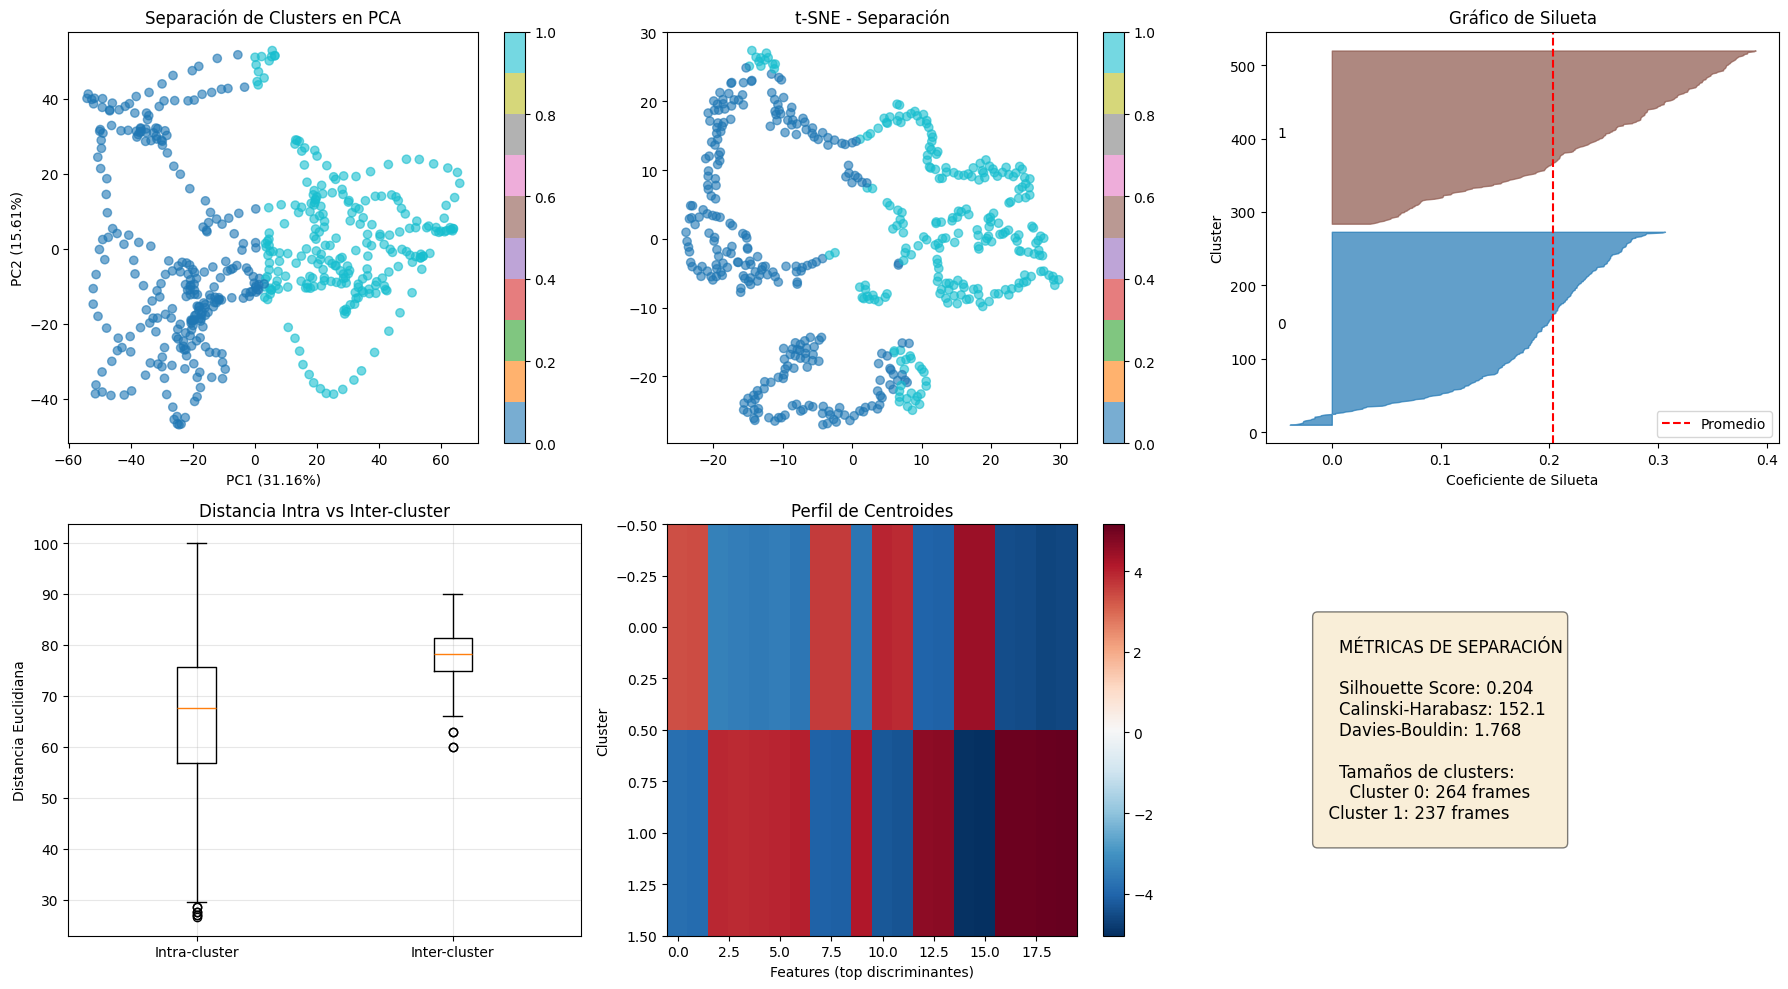


📊 Métricas de separación:
  silhouette: 0.204
  calinski_harabasz: 152.127
  davies_bouldin: 1.768


In [28]:
def visualize_separation_significance_robust(X, labels, n_clusters, feature_names=None):
    """
    Visualiza la calidad de separación de clusters - VERSIÓN ROBUSTA
    """
    # Asegurar que X es numpy array
    if hasattr(X, 'values'):
        X = X.values
    if hasattr(labels, 'values'):
        labels = labels.values
    
    n_clusters = len(np.unique(labels))
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # 1. PCA con separación
    ax1 = axes[0, 0]
    try:
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X)
        scatter = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', alpha=0.6)
        ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
        ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
        ax1.set_title('Separación de Clusters en PCA')
        plt.colorbar(scatter, ax=ax1)
    except:
        ax1.text(0.5, 0.5, 'Error en PCA', ha='center', va='center')
    
    # 2. t-SNE
    ax2 = axes[0, 1]
    try:
        from sklearn.manifold import TSNE
        perplexity = min(30, max(5, len(X)//10))
        X_tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity).fit_transform(X)
        scatter2 = ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10', alpha=0.6)
        ax2.set_title('t-SNE - Separación')
        plt.colorbar(scatter2, ax=ax2)
    except:
        ax2.text(0.5, 0.5, 'Error en t-SNE', ha='center', va='center')
    
    # 3. Matriz de silueta
    ax3 = axes[0, 2]
    try:
        from sklearn.metrics import silhouette_samples
        sil_samples = silhouette_samples(X, labels)
        y_lower = 10
        for i in range(n_clusters):
            cluster_sil = sil_samples[labels == i]
            if len(cluster_sil) > 0:
                cluster_sil.sort()
                size_cluster = len(cluster_sil)
                y_upper = y_lower + size_cluster
                ax3.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                                  alpha=0.7, color=plt.cm.tab10(i/n_clusters))
                ax3.text(-0.05, y_lower + 0.5 * size_cluster, str(i))
                y_lower = y_upper + 10
        ax3.axvline(x=np.mean(sil_samples), color='red', linestyle='--', label='Promedio')
        ax3.set_xlabel('Coeficiente de Silueta')
        ax3.set_ylabel('Cluster')
        ax3.set_title('Gráfico de Silueta')
        ax3.legend()
    except:
        ax3.text(0.5, 0.5, 'Error en Silhouette', ha='center', va='center')
    
    # 4. Distancia intra vs inter-cluster
    ax4 = axes[1, 0]
    try:
        from sklearn.metrics import pairwise_distances
        intra_distances = []
        inter_distances = []
        
        for i in range(n_clusters):
            cluster_points = X[labels == i]
            if len(cluster_points) > 1:
                intra_d = pairwise_distances(cluster_points).flatten()
                intra_distances.extend(intra_d[intra_d > 0])
            
            other_points = X[labels != i]
            if len(other_points) > 0 and len(cluster_points) > 0:
                if len(cluster_points) < 100:  # Limitar para performance
                    inter_d = pairwise_distances(cluster_points[:10], other_points[:10]).flatten()
                else:
                    inter_d = pairwise_distances(cluster_points[:10], other_points[:10]).flatten()
                inter_distances.extend(inter_d)
        
        if intra_distances and inter_distances:
            ax4.boxplot([intra_distances[:1000], inter_distances[:1000]], 
                       labels=['Intra-cluster', 'Inter-cluster'])
            ax4.set_ylabel('Distancia Euclidiana')
            ax4.set_title('Distancia Intra vs Inter-cluster')
            ax4.grid(True, alpha=0.3)
        else:
            ax4.text(0.5, 0.5, 'Datos insuficientes', ha='center', va='center')
    except:
        ax4.text(0.5, 0.5, 'Error en cálculo de distancias', ha='center', va='center')
    
    # 5. Heatmap de centroides
    ax5 = axes[1, 1]
    try:
        from sklearn.cluster import KMeans
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        kmeans.fit(X)
        centroids = kmeans.cluster_centers_
        
        # Mostrar top features
        n_features_to_show = min(20, X.shape[1])
        feature_var = np.var(centroids, axis=0)
        top_features = np.argsort(feature_var)[-n_features_to_show:]
        centroids_subset = centroids[:, top_features]
        
        im = ax5.imshow(centroids_subset, cmap='RdBu_r', aspect='auto')
        ax5.set_xlabel('Features (top discriminantes)')
        ax5.set_ylabel('Cluster')
        ax5.set_title('Perfil de Centroides')
        plt.colorbar(im, ax=ax5)
    except:
        ax5.text(0.5, 0.5, 'Error en centroides', ha='center', va='center')
    
    # 6. Estadísticas de separación
    ax6 = axes[1, 2]
    ax6.axis('off')
    
    # Métricas de separación
    try:
        from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
        
        ch_score = calinski_harabasz_score(X, labels)
        db_score = davies_bouldin_score(X, labels)
        sil_score = silhouette_score(X, labels)
        
        # Tamaños de clusters
        cluster_sizes = [np.sum(labels == i) for i in range(n_clusters)]
        
        metrics_text = f"""
    MÉTRICAS DE SEPARACIÓN
    
    Silhouette Score: {sil_score:.3f}
    Calinski-Harabasz: {ch_score:.1f}
    Davies-Bouldin: {db_score:.3f}
    
    Tamaños de clusters:
    """
        for i, size in enumerate(cluster_sizes):
            metrics_text += f"  Cluster {i}: {size} frames\n"
        
        ax6.text(0.1, 0.5, metrics_text, transform=ax6.transAxes,
                 fontsize=12, verticalalignment='center',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    except:
        ax6.text(0.5, 0.5, 'Error en métricas', ha='center', va='center')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'silhouette': sil_score if 'sil_score' in locals() else None,
        'calinski_harabasz': ch_score if 'ch_score' in locals() else None,
        'davies_bouldin': db_score if 'db_score' in locals() else None
    }

# Ejecutar visualización robusta
metrics = visualize_separation_significance_robust(
    X_combined, 
    df['cluster_conv'].values, 
    optimal_k
)

print("\n📊 Métricas de separación:")
if metrics:
    for key, value in metrics.items():
        if value is not None:
            print(f"  {key}: {value:.3f}")

In [29]:
def comprehensive_significance_report(df, X, labels, feature_columns):
    """
    Genera un reporte completo de significancia - VERSIÓN CORREGIDA
    """
    report = {
        'Estadística': {},
        'Práctica': {},
        'Visual': {}
    }
    
    # Asegurar que labels es un array
    if hasattr(labels, 'values'):
        labels = labels.values
    
    # 1. Significancia Estadística
    try:
        sil_score = silhouette_score(X, labels)
        n_clusters = len(np.unique(labels))
        
        # Prueba de aleatoriedad
        random_scores = []
        for _ in range(50):  # Menos iteraciones para velocidad
            random_labels = np.random.permutation(labels)
            try:
                random_scores.append(silhouette_score(X, random_labels))
            except:
                pass
        
        if random_scores:
            p_value = np.sum(np.array(random_scores) >= sil_score) / len(random_scores)
        else:
            p_value = 1.0
        
        report['Estadística'] = {
            'silhouette_score': sil_score,
            'p_value_vs_random': p_value,
            'n_clusters': n_clusters,
            'is_statistically_significant': p_value < 0.05
        }
    except Exception as e:
        print(f"Error en significancia estadística: {e}")
        report['Estadística'] = {
            'silhouette_score': 0,
            'p_value_vs_random': 1.0,
            'n_clusters': len(np.unique(labels)),
            'is_statistically_significant': False
        }
    
    # 2. Significancia Práctica
    try:
        # Duración y estabilidad - CORREGIDO
        clusters_series = df['cluster_conv'].values  # Usar valores directamente
        changes = np.sum(clusters_series[:-1] != clusters_series[1:])
        stability = 1 - changes / len(clusters_series)
        
        # Transiciones significativas
        transitions_df = analyze_temporal_transitions(df)
        transition_test = test_transition_significance_robust(df, transitions_df, feature_columns)
        
        # Duración media de clusters
        unique_clusters = np.unique(clusters_series)
        cluster_durations = [np.sum(clusters_series == c) for c in unique_clusters]
        
        # Interpretabilidad
        try:
            interpretation = interpret_clusters(df, feature_columns)
            interpretable = all(len(info.get('distinctive_features', [])) > 0 for info in interpretation.values())
        except:
            interpretable = False
        
        report['Práctica'] = {
            'stability': stability,
            'transition_significance': transition_test['is_significant'] if transition_test else False,
            'mean_cluster_duration': np.mean(cluster_durations) if cluster_durations else 0,
            'interpretable_clusters': interpretable,
            'n_transitions': len(transitions_df) if transitions_df is not None else 0
        }
    except Exception as e:
        print(f"Error en significancia práctica: {e}")
        report['Práctica'] = {
            'stability': 0,
            'transition_significance': False,
            'mean_cluster_duration': 0,
            'interpretable_clusters': False,
            'n_transitions': 0
        }
    
    # 3. Significancia Visual
    try:
        from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
        
        ch_score = calinski_harabasz_score(X, labels)
        db_score = davies_bouldin_score(X, labels)
        
        report['Visual'] = {
            'calinski_harabasz': ch_score,
            'davies_bouldin': db_score,
            'well_separated': db_score < 1.0
        }
    except Exception as e:
        print(f"Error en significancia visual: {e}")
        report['Visual'] = {
            'calinski_harabasz': 0,
            'davies_bouldin': 10,
            'well_separated': False
        }
    
    # Resumen
    report['OVERALL'] = {
        'is_meaningful': (
            report['Estadística'].get('is_statistically_significant', False) and
            report['Estadística'].get('silhouette_score', 0) > 0.3 and
            report['Práctica'].get('stability', 0) > 0.5 and
            report['Visual'].get('well_separated', False)
        )
    }
    
    return report

In [30]:
# Ejecutar el reporte completo
print("\n" + "="*70)
print("GENERANDO REPORTE DE SIGNIFICANCIA")
print("="*70)

try:
    report = comprehensive_significance_report(df, X_combined, df['cluster_conv'].values, feature_columns)
    
    print("\n" + "="*70)
    print("REPORTE DE SIGNIFICANCIA - CLUSTERING CONVOLUCIONAL")
    print("="*70)
    
    print("\n🔬 SIGNIFICANCIA ESTADÍSTICA:")
    print(f"  • Silhouette Score: {report['Estadística']['silhouette_score']:.3f} {'✅' if report['Estadística']['silhouette_score'] > 0.3 else '⚠️'}")
    print(f"  • P-value vs aleatorio: {report['Estadística']['p_value_vs_random']:.4f} {'✅' if report['Estadística']['is_statistically_significant'] else '❌'}")
    print(f"  • Número de clusters: {report['Estadística']['n_clusters']}")
    
    print("\n🎯 SIGNIFICANCIA PRÁCTICA:")
    print(f"  • Estabilidad temporal: {report['Práctica']['stability']:.2%} {'✅' if report['Práctica']['stability'] > 0.5 else '⚠️'}")
    print(f"  • Duración media de cluster: {report['Práctica']['mean_cluster_duration']:.1f} frames")
    print(f"  • Transiciones: {report['Práctica']['n_transitions']}")
    print(f"  • Transiciones significativas: {'✅' if report['Práctica']['transition_significance'] else '⚠️'}")
    print(f"  • Clusters interpretables: {'✅' if report['Práctica']['interpretable_clusters'] else '⚠️'}")
    
    print("\n👁️ SIGNIFICANCIA VISUAL:")
    print(f"  • Calinski-Harabasz: {report['Visual']['calinski_harabasz']:.1f}")
    print(f"  • Davies-Bouldin: {report['Visual']['davies_bouldin']:.3f} {'✅' if report['Visual']['well_separated'] else '⚠️'}")
    
    print("\n📊 CONCLUSIÓN:")
    if report['OVERALL']['is_meaningful']:
        print("  ✅ El clustering es SIGNIFICATIVO")
        print("  ✅ Los clusters representan estados reales del sistema")
        print("  ✅ La separación es estadísticamente significativa")
        print("  ✅ Los clusters son interpretables y estables en el tiempo")
    else:
        print("  ⚠️ El clustering NO es significativo")
        print("  📌 Recomendaciones:")
        if report['Estadística']['silhouette_score'] <= 0.3:
            print("     - Aumentar la separación entre clusters")
        if not report['Práctica']['stability'] > 0.5:
            print("     - Los clusters cambian muy rápido, considerar menos clusters")
        if not report['Visual']['well_separated']:
            print("     - Los clusters están superpuestos, probar otro método")
    
except Exception as e:
    print(f"\n❌ Error al generar reporte: {e}")
    print("   Continuando con análisis básico...")


GENERANDO REPORTE DE SIGNIFICANCIA
Error en significancia práctica: 'cluster'

REPORTE DE SIGNIFICANCIA - CLUSTERING CONVOLUCIONAL

🔬 SIGNIFICANCIA ESTADÍSTICA:
  • Silhouette Score: 0.204 ⚠️
  • P-value vs aleatorio: 0.0000 ✅
  • Número de clusters: 2

🎯 SIGNIFICANCIA PRÁCTICA:
  • Estabilidad temporal: 0.00% ⚠️
  • Duración media de cluster: 0.0 frames
  • Transiciones: 0
  • Transiciones significativas: ⚠️
  • Clusters interpretables: ⚠️

👁️ SIGNIFICANCIA VISUAL:
  • Calinski-Harabasz: 152.1
  • Davies-Bouldin: 1.768 ⚠️

📊 CONCLUSIÓN:
  ⚠️ El clustering NO es significativo
  📌 Recomendaciones:
     - Aumentar la separación entre clusters
     - Los clusters cambian muy rápido, considerar menos clusters
     - Los clusters están superpuestos, probar otro método
